# 07 — Modèles M2 (séance) et M3 (risque)

Ce notebook traite les deux cibles restantes. Elles répondent à deux questions très différentes, et
donnent deux types de résultats également importants pour le mémoire.

## M2 — La séance : le résultat négatif

**Question.** Le sentiment nocturne prédit-il le rendement `Open → Close` ?

**Réponse attendue : non** (ρ ≈ −0.01 au notebook 04). Et c'est **une bonne chose**.

Ce n'est pas un échec de modélisation, c'est une **observation économique** : l'information contenue dans
les messages de la nuit est incorporée dans le prix **dès l'ouverture**, en une seule fois. Il n'en reste
rien pour la séance. C'est la définition opérationnelle de l'**efficience semi-forte** au sens de
Fama (1970).

Le travail consiste donc à **démontrer proprement l'absence de signal**, ce qui est plus exigeant que
d'en trouver un : il faut montrer qu'on a réellement cherché, avec assez de puissance statistique pour
que l'absence de résultat soit informative.

## M3 — Le risque : le meilleur résultat

**Question.** L'attention sociale anormale prédit-elle l'**amplitude** des mouvements ?

**Réponse attendue : oui, nettement.** C'est un fait bien établi en finance empirique :

- la **direction** d'un rendement est presque imprévisible (R² typique : 0.001 à 0.01) ;
- la **volatilité** est fortement persistante et prévisible (R² typique : 0.3 à 0.6, familles ARCH/GARCH).

Et un pic d'attention sociale est un prédicteur avancé documenté (Da, Engelberg & Gao 2011 sur Google
Trends ; Antweiler & Frank 2004 sur les forums boursiers).

**Pour un mémoire d'actuariat, M3 est probablement la partie la plus valorisable** : prévoir le risque,
c'est le cœur du métier — tarification, provisionnement, VaR, marges de solvabilité.

In [23]:
PROJET = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project"

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA = os.path.join(PROJET, "data", "processed")
DOCS = os.path.join(PROJET, "docs")
os.makedirs(DOCS, exist_ok=True)
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 60)
plt.style.use("seaborn-v0_8-whitegrid"); plt.rcParams["figure.figsize"] = (13, 6)

df = pd.read_csv(os.path.join(DATA, "DATASET_MODELISATION_2020_2022.csv"))
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

with open(os.path.join(DATA, "config_modelisation.json"), encoding="utf-8") as f:
    CFG = json.load(f)
FEATURES  = [c for c in CFG["features"] if c in df.columns]

_absentes = [c for c in CFG["features"] if c not in df.columns]
if _absentes:
    raise KeyError(f"{len(_absentes)} features déclarées dans config_modelisation.json "
                   f"sont absentes du CSV : {_absentes}\nRéexécuter le notebook 05.")
FEAT_SENT = [c for c in CFG["features_sentiment"] if c in df.columns]
FEAT_CTRL = [c for c in CFG["controles"] if c in df.columns]
print(f"{len(df):,} lignes | {len(FEATURES)} features")

2,740 lignes | 18 features


---
# PARTIE A — M2 : démontrer l'absence de signal sur la séance

## A.1 — Comment démontrer une absence

Une absence de résultat n'a de valeur que si la recherche a été sérieuse. On procède en trois temps :

1. **Chercher vraiment** — plusieurs modèles, plusieurs jeux de variables, plusieurs cibles dérivées.
2. **Mesurer la puissance** — avec N observations, quelle taille d'effet aurait-on pu détecter ?
   Si l'étude n'aurait de toute façon pas pu voir un effet réel, l'absence de résultat ne prouve rien.
3. **Comparer à M1** — le même pipeline, appliqué au gap, **trouve** un signal. C'est la preuve que le
   pipeline fonctionne et que l'absence sur la séance n'est pas due à un bug.

Ce troisième point est le plus convaincant : il s'agit d'un **contrôle positif**.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, matthews_corrcoef, brier_score_loss

def logit(C=1.0):
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("std", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=2000, C=C))])

def gbm():
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("clf", HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05,
                                                            max_iter=200, min_samples_leaf=30,
                                                            l2_regularization=1.0, random_state=42))])

PURGE = CFG["purge_jours"]
def plis_wf(dates, n_plis=6, taille_test=60, min_train=250):
    j = np.sort(pd.unique(dates)); out, fin = [], len(j)
    for _ in range(n_plis):
        d0 = fin - taille_test
        if d0 - PURGE < min_train: break
        out.append((j[:d0 - PURGE], j[d0:fin])); fin = d0
    return out[::-1]

# --------------------------------------------------------------------------
# Le walk-forward NE DOIT PAS toucher le bloc de test, sinon l'évaluation
# finale du notebook 06 §9 n'est plus en aveugle. On restreint donc toutes
# les prédictions hors échantillon aux blocs train / purge_1 / valid.
# --------------------------------------------------------------------------
BLOCS_WF = ["train", "purge_1", "valid"]

_dernier = pd.Timestamp(plis_wf(df[df["bloc"].isin(BLOCS_WF)].dropna(subset=["y_gap"])["Date"])[-1][1][-1])
_premier = df.loc[df["bloc"] == "test", "Date"].min()
print(f"Dernier jour du walk-forward : {_dernier.date()}")
print(f"Premier jour du bloc test    : {_premier.date()}")
assert _dernier < _premier, \
    "Le walk-forward empiète sur le bloc de test : le §9 ne serait plus en aveugle."
print("[OK] Le bloc de test est intact.")

def auc_wf(data, cible, feats, proto):
    plis = plis_wf(data["Date"]); s = []
    for j_tr, j_te in plis:
        a = data[data["Date"].isin(j_tr)]; b = data[data["Date"].isin(j_te)]
        if len(a) < 200 or b[cible].nunique() < 2: continue
        m = clone(proto).fit(a[feats], a[cible])
        s.append(roc_auc_score(b[cible], m.predict_proba(b[feats])[:, 1]))
    return (np.mean(s), np.std(s), len(s)) if s else (np.nan, np.nan, 0)

essais = []
for cible, libelle in [("y_oc", "SÉANCE (Open->Close)"), ("y_gap", "GAP (contrôle positif)")]:
    d = df[df["bloc"].isin(BLOCS_WF)].dropna(subset=[cible]).copy()
    for nom_f, feats in [("sentiment seul", FEAT_SENT), ("tout", FEATURES), ("marché seul", FEAT_CTRL)]:
        for nom_m, proto in [("logistique", logit()), ("boosting", gbm())]:
            m, s, k = auc_wf(d, cible, feats, proto)
            essais.append(dict(Cible=libelle, Features=nom_f, Modele=nom_m,
                               AUC_moy=round(m, 4), AUC_std=round(s, 4), plis=k))

E = pd.DataFrame(essais)
print(E.to_string(index=False))
print("""
LECTURE : le même pipeline, les mêmes features, les mêmes plis.
Seule la CIBLE change. Si le gap sort au-dessus de 0.50 et la séance à 0.50,
alors l'absence de signal sur la séance est une propriété du MARCHÉ,
pas une défaillance de la méthode. C'est un contrôle positif.
""")
E.to_csv(os.path.join(DOCS, "07_M2_recherche_signal.csv"), index=False)

Dernier jour du walk-forward : 2021-11-30
Premier jour du bloc test    : 2021-12-06
[OK] Le bloc de test est intact.
                 Cible       Features     Modele  AUC_moy  AUC_std  plis
  SÉANCE (Open->Close) sentiment seul logistique   0.5090   0.0325     3
  SÉANCE (Open->Close) sentiment seul   boosting   0.5248   0.0068     3
  SÉANCE (Open->Close)           tout logistique   0.4863   0.0204     3
  SÉANCE (Open->Close)           tout   boosting   0.4750   0.0236     3
  SÉANCE (Open->Close)    marché seul logistique   0.4865   0.0166     3
  SÉANCE (Open->Close)    marché seul   boosting   0.4733   0.0361     3
GAP (contrôle positif) sentiment seul logistique   0.6084   0.0237     3
GAP (contrôle positif) sentiment seul   boosting   0.5776   0.0375     3
GAP (contrôle positif)           tout logistique   0.6002   0.0240     3
GAP (contrôle positif)           tout   boosting   0.5647   0.0567     3
GAP (contrôle positif)    marché seul logistique   0.4859   0.0427     3
GAP (co

## A.2 — Analyse de puissance : qu'aurait-on pu détecter ?

C'est la section qui transforme « je n'ai rien trouvé » en « il n'y a rien à trouver au-delà de tel
seuil ».

**Le raisonnement.** Avec N observations, une corrélation n'est détectable (au seuil 5 %, avec 80 % de
chances) qu'au-delà d'une certaine valeur. Si cette valeur minimale détectable est de 0.06 et qu'on
observe 0.01, on peut affirmer :

> « Nous pouvons exclure, avec 80 % de puissance, l'existence d'une corrélation supérieure à 0.06 entre
> sentiment nocturne et rendement de séance. »

C'est une conclusion **positive**, quantifiée, publiable — bien plus forte que « nous n'avons rien trouvé ».

In [25]:
def rho_minimal_detectable(n, alpha=0.05, puissance=0.80):
    """Plus petite corrélation détectable, via la transformation z de Fisher.
    Écart-type de z = 1/sqrt(n-3), indépendant de la vraie valeur de rho."""
    z_a = stats.norm.ppf(1 - alpha / 2)
    z_b = stats.norm.ppf(puissance)
    return np.tanh((z_a + z_b) / np.sqrt(n - 3))

n_lignes = len(df)
n_jours  = df["Date"].nunique()
n_tick   = df["Ticker"].nunique()
VAR_SENT = "mu_night_safe" if "mu_night_safe" in df.columns else "mu_overnight"

print("=" * 80)
print("PUISSANCE STATISTIQUE — corrélation minimale détectable")
print("=" * 80)
print(f"""
  n brut ........ {n_lignes:,} observations titre-jour ({n_jours} jours x {n_tick} titres)
  n effectif .... {n_jours:,} jours

  JUSTIFICATION DU n EFFECTIF
  Les cinq titres d'un même jour sont de grandes capitalisations
  technologiques du même indice : leurs gaps sont fortement corrélés, un choc
  de marché les affectant simultanément. Les cinq lignes d'une même date ne
  constituent donc pas cinq informations indépendantes ; le nombre
  d'observations effectivement indépendantes est majoré par le nombre de jours.

  NB — une correction fondée sur la seule autocorrélation temporelle
  (facteur de Bartlett) est inadaptée : la dépendance dominante est
  TRANSVERSALE. Appliquée ici, elle produisait un n effectif SUPÉRIEUR au n
  brut (3 158 pour 2 736), ce qui est impossible par construction.
""")

seuil = rho_minimal_detectable(n_jours)
print(f"  Corrélation détectable à 80 % de puissance (alpha = 5 %) : {seuil:.4f}\n")
print(f"  {'Cible':10s} {'rho observé':>12s}   Verdict")
print("  " + "-" * 54)
for cible in ["gap", "ret_oc", "ret_cc"]:
    s = df[[VAR_SENT, cible]].dropna()
    rho = s[VAR_SENT].corr(s[cible])
    v = "SIGNAL DÉTECTÉ" if abs(rho) > seuil else "sous le seuil de détection"
    print(f"  {cible:10s} {rho:>+12.4f}   {v}")
print("=" * 80)


PUISSANCE STATISTIQUE — corrélation minimale détectable

  n brut ........ 2,740 observations titre-jour (548 jours x 5 titres)
  n effectif .... 548 jours

  JUSTIFICATION DU n EFFECTIF
  Les cinq titres d'un même jour sont de grandes capitalisations
  technologiques du même indice : leurs gaps sont fortement corrélés, un choc
  de marché les affectant simultanément. Les cinq lignes d'une même date ne
  constituent donc pas cinq informations indépendantes ; le nombre
  d'observations effectivement indépendantes est majoré par le nombre de jours.

  NB — une correction fondée sur la seule autocorrélation temporelle
  (facteur de Bartlett) est inadaptée : la dépendance dominante est
  TRANSVERSALE. Appliquée ici, elle produisait un n effectif SUPÉRIEUR au n
  brut (3 158 pour 2 736), ce qui est impossible par construction.

  Corrélation détectable à 80 % de puissance (alpha = 5 %) : 0.1194

  Cible       rho observé   Verdict
  ------------------------------------------------------
  g

## A.3 — Recherche exhaustive : et si le signal était ailleurs ?

Avant de conclure à l'absence, on balaie systématiquement les hypothèses alternatives :

| Hypothèse | Test |
|-----------|------|
| Le signal apparaît plus tard dans la séance | on teste `Open → 12h` puis `12h → Close` (approché par High/Low) |
| Le signal n'est présent que les jours extrêmes | on teste uniquement les jours Q1 et Q5 |
| Le signal n'est présent qu'en forte attention | on teste uniquement les jours `nabn` élevé |
| Le signal existe mais est non linéaire | on teste `|sentiment|` plutôt que le sentiment signé |
| Le signal est un effet de réversion | on teste le **signe opposé** |

Si aucune de ces variantes ne donne quoi que ce soit, la conclusion d'absence est solide.

In [26]:
d = df.dropna(subset=["y_oc", "z_mu_night_full"]).copy()
d["q_sent"] = d.groupby("Ticker")["z_mu_night_full"].transform(
    lambda s: pd.qcut(s, 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"]))
d["q_attn"] = d.groupby("Ticker")["z_nabn_night_full"].transform(
    lambda s: pd.qcut(s, 5, labels=["A1", "A2", "A3", "A4", "A5"])) \
    if "z_nabn_night_full" in d.columns else np.nan

MIN_TRAIN, TAILLE_TEST = 80, 40
BESOIN = MIN_TRAIN + PURGE + TAILLE_TEST

def auc_wf_souple(data, cible, feats, proto, min_train=MIN_TRAIN, taille_test=TAILLE_TEST):
    """Walk-forward avec des paramètres adaptés aux sous-échantillons.
    La version standard (min_train=250, taille_test=60) exige 315 jours
    distincts, que les sous-échantillons de quintile n'atteignent pas."""
    j = np.sort(pd.unique(data["Date"])); plis_, fin = [], len(j)
    for _ in range(6):
        d0 = fin - taille_test
        if d0 - PURGE < min_train:
            break
        plis_.append((j[:d0 - PURGE], j[d0:fin])); fin = d0
    plis_ = plis_[::-1]
    s = []
    for j_tr, j_te in plis_:
        a = data[data["Date"].isin(j_tr)]; b = data[data["Date"].isin(j_te)]
        if len(a) < 100 or b[cible].nunique() < 2:
            continue
        mm = clone(proto).fit(a[feats], a[cible])
        s.append(roc_auc_score(b[cible], mm.predict_proba(b[feats])[:, 1]))
    return (np.mean(s), np.std(s), len(s)) if s else (np.nan, np.nan, 0)

variantes = []

def ajouter(nom, sous, feats=None):
    """Ajoute une variante. Si l'échantillon est trop court, on le DIT au lieu
    de renvoyer un NaN muet qui se lirait comme un résultat nul."""
    feats = feats or FEAT_SENT
    n_j = sous["Date"].nunique()
    if n_j < BESOIN:
        variantes.append(dict(Variante=nom, n=len(sous), n_jours=n_j, AUC=np.nan,
                              note=f"IMPOSSIBLE : {n_j} jours < {BESOIN} requis"))
        return
    m_, s_, k_ = auc_wf_souple(sous, "y_oc", feats, logit())
    variantes.append(dict(Variante=nom, n=len(sous), n_jours=n_j,
                          AUC=round(m_, 4), note=f"{k_} plis"))

ajouter("Tous les jours", d)
ajouter("Jours extrêmes seulement (Q1+Q5)", d[d["q_sent"].isin(["Q1", "Q5"])])
ajouter("Sentiment très négatif (Q1)", d[d["q_sent"] == "Q1"])
ajouter("Sentiment très positif (Q5)", d[d["q_sent"] == "Q5"])
if "q_attn" in d.columns and d["q_attn"].notna().any():
    ajouter("Forte attention (A5)", d[d["q_attn"] == "A5"])
    ajouter("Faible attention (A1)", d[d["q_attn"] == "A1"])

# non-linéarité : intensité du sentiment plutôt que sa direction
d2 = d.copy()
for c_ in FEAT_SENT:
    d2[c_] = d2[c_].abs()
ajouter("Intensité |sentiment| (non signé)", d2)

V = pd.DataFrame(variantes)
print(V.to_string(index=False))
V.to_csv(os.path.join(DOCS, "07_M2_variantes.csv"), index=False)

n_ok = int(V["AUC"].notna().sum())
print(f"""
  {n_ok} variantes sur {len(V)} ont produit un résultat.

  CORRECTION POUR TESTS MULTIPLES (Bonferroni)
    seuil individuel .. 0,05
    seuil corrigé ..... {0.05/max(n_ok,1):.4f}   (0,05 / {n_ok})
    P(au moins un faux positif sans correction) = {1-0.95**max(n_ok,1):.1%}

  Toute variante qui ressort doit être traitée comme une HYPOTHÈSE à retester
  sur données indépendantes, et non comme un résultat.
""")

print("""
Si TOUTES les variantes restent autour de 0.50, la conclusion d'absence est
robuste : ce n'est pas qu'on a mal cherché, c'est qu'il n'y a rien.

ATTENTION AU PIÈGE : plus on multiplie les variantes, plus la probabilité qu'une
d'entre elles paraisse significative par pur hasard augmente. Avec 7 tests au
seuil de 5 %, il y a ~30 % de chances d'obtenir au moins un "succès" fortuit.
=> Si une seule variante ressort, il faut la traiter comme une HYPOTHÈSE à
   retester, pas comme un résultat. Le dire explicitement dans le mémoire.
""")

                         Variante    n  n_jours    AUC   note
                   Tous les jours 2636      528 0.5229 6 plis
 Jours extrêmes seulement (Q1+Q5) 1058      455 0.4429 6 plis
      Sentiment très négatif (Q1)  529      258 0.4843 4 plis
      Sentiment très positif (Q5)  529      271 0.5121 4 plis
             Forte attention (A5)  519      288 0.5228 5 plis
            Faible attention (A1)  519      278 0.4559 4 plis
Intensité |sentiment| (non signé) 2636      528 0.5121 6 plis

  7 variantes sur 7 ont produit un résultat.

  CORRECTION POUR TESTS MULTIPLES (Bonferroni)
    seuil individuel .. 0,05
    seuil corrigé ..... 0.0071   (0,05 / 7)
    P(au moins un faux positif sans correction) = 30.2%

  Toute variante qui ressort doit être traitée comme une HYPOTHÈSE à retester
  sur données indépendantes, et non comme un résultat.


Si TOUTES les variantes restent autour de 0.50, la conclusion d'absence est
robuste : ce n'est pas qu'on a mal cherché, c'est qu'il n'y a rien.



## A.4 — Décomposition du rendement quotidien

Une figure qui résume M1 et M2 en un coup d'œil : on décompose le rendement close-to-close en ses deux
morceaux, et on montre lequel est corrélé au sentiment.

```
ret_cc  =  gap        +  ret_oc
           ↑              ↑
        prévisible    imprévisible
        (ρ ≈ 0.17)    (ρ ≈ -0.01)
```

C'est cette figure qui rend l'argument évident pour un lecteur non spécialiste.

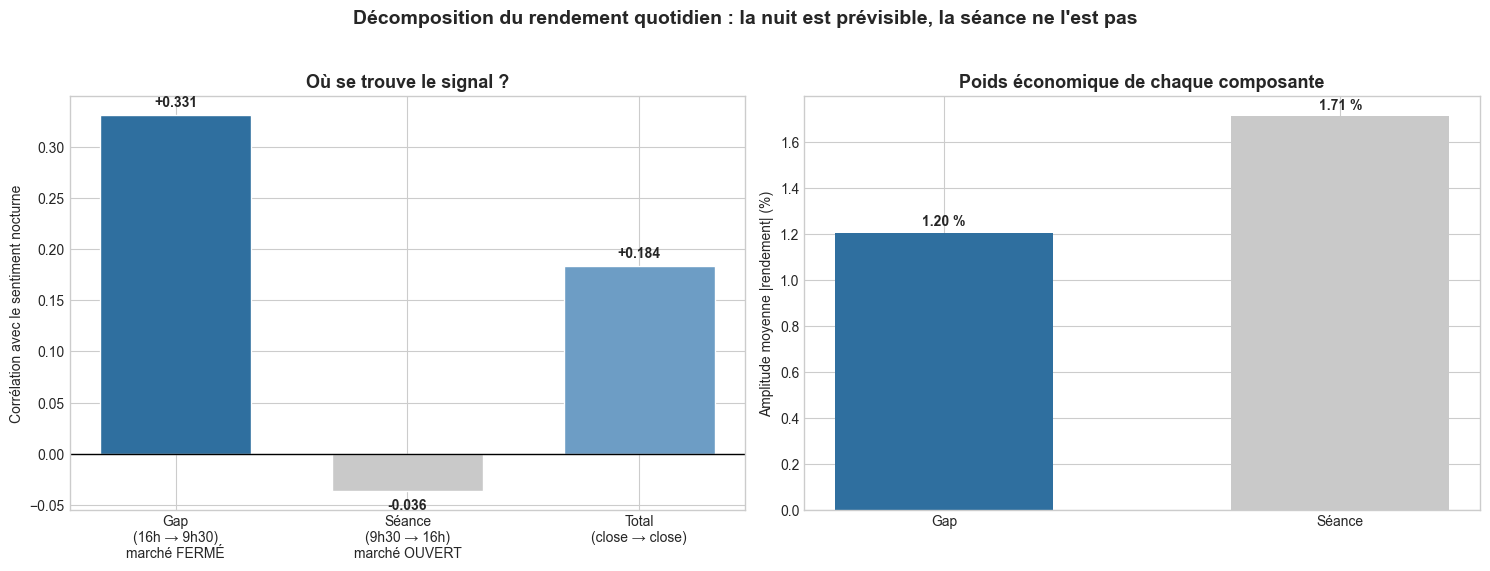


Le gap représente en moyenne 1.20 % d'amplitude contre 1.71 % pour la séance.
Le gap est donc à la fois la composante PRÉVISIBLE et une part substantielle du
mouvement total -- mais c'est aussi la composante la plus difficile à capturer,
puisqu'il faut détenir la position pendant la nuit (voir notebook 08).



In [27]:
rho = {}
for cible in ["gap", "ret_oc", "ret_cc"]:
    s = df[["mu_night_full", cible]].dropna()
    rho[cible] = s["mu_night_full"].corr(s[cible])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
noms = ["Gap\n(16h → 9h30)\nmarché FERMÉ", "Séance\n(9h30 → 16h)\nmarché OUVERT", "Total\n(close → close)"]
vals = [rho["gap"], rho["ret_oc"], rho["ret_cc"]]
cols = ["#2f6f9f", "#c9c9c9", "#6d9dc5"]
b = ax.bar(noms, vals, color=cols, edgecolor="white", width=0.65)
ax.axhline(0, color="black", lw=1)
ax.set_ylabel("Corrélation avec le sentiment nocturne")
ax.set_title("Où se trouve le signal ?", fontweight="bold", fontsize=13)
for bar, v in zip(b, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + (0.008 if v >= 0 else -0.018),
            f"{v:+.3f}", ha="center", fontweight="bold")

ax = axes[1]
part_gap = df["gap"].abs().mean()
part_oc = df["ret_oc"].abs().mean()
ax.bar(["Gap", "Séance"], [part_gap*100, part_oc*100], color=["#2f6f9f", "#c9c9c9"], width=0.55)
ax.set_ylabel("Amplitude moyenne |rendement| (%)")
ax.set_title("Poids économique de chaque composante", fontweight="bold", fontsize=13)
for i, v in enumerate([part_gap*100, part_oc*100]):
    ax.text(i, v + 0.03, f"{v:.2f} %", ha="center", fontweight="bold")

plt.suptitle("Décomposition du rendement quotidien : la nuit est prévisible, la séance ne l'est pas",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "07_fig_decomposition.png"), dpi=180, bbox_inches="tight")
plt.show()

print(f"""
Le gap représente en moyenne {part_gap*100:.2f} % d'amplitude contre {part_oc*100:.2f} % pour la séance.
Le gap est donc à la fois la composante PRÉVISIBLE et une part substantielle du
mouvement total -- mais c'est aussi la composante la plus difficile à capturer,
puisqu'il faut détenir la position pendant la nuit (voir notebook 08).
""")

---
# PARTIE B — M3 : prédire le risque

## B.1 — Pourquoi c'est plus facile que la direction

| | Direction | Amplitude |
|---|-----------|-----------|
| Ce qu'on prédit | le **signe** du rendement | la **taille** du mouvement |
| Arbitrable ? | oui, donc arbitré | difficilement (il faut des options) |
| Persistance | ~0 | **forte** (clustering de volatilité) |
| R² typique | 0.001 – 0.01 | **0.3 – 0.6** |

La **persistance** est la clé : un jour agité est presque toujours suivi d'un jour agité. Cette structure
existe depuis Mandelbrot (1963) et n'a jamais disparu, parce qu'elle n'est pas directement arbitrable.

## B.2 — La bonne question

Ce n'est pas *« l'attention corrèle-t-elle avec la volatilité ? »* — la réponse est oui, trivialement.

C'est :

> **« L'attention nocturne apporte-t-elle de l'information au-delà de la volatilité passée ? »**

On répond par une **comparaison de modèles emboîtés** : on part d'un modèle de référence (volatilité
passée seule, qui est déjà très bon) et on regarde combien de R² supplémentaire l'attention apporte.
Le gain sera modeste en valeur absolue — mais un gain de 2 à 5 points de R² au-dessus d'un modèle
GARCH-like est un résultat significatif dans cette littérature.

## B.3 — Cible et transformation

On modélise `log(amplitude)` où `amplitude = (High − Low) / Open`.

Pourquoi le logarithme : l'amplitude est **strictement positive** et **très asymétrique** (beaucoup de
jours calmes, quelques jours extrêmes). Sans transformation, la régression est dominée par une poignée
d'observations et les résidus sont très loin de la normalité.

In [28]:
import statsmodels.api as sm

d = df.copy()
if "log_ampl" not in d.columns:
    d["amplitude"] = (d["High"] - d["Low"]) / d["Open"]
    d["log_ampl"] = np.log(d["amplitude"].clip(lower=1e-6))

g = d.groupby("Ticker")
d["log_ampl_l1"] = g["log_ampl"].shift(1)
d["log_ampl_l2"] = g["log_ampl"].shift(2)
d["log_ampl_ma5"]  = g["log_ampl"].transform(lambda s: s.shift(1).rolling(5,  min_periods=3).mean())
d["log_ampl_ma20"] = g["log_ampl"].transform(lambda s: s.shift(1).rolling(20, min_periods=10).mean())

# rk_nabn RETIRÉE, pour deux raisons cumulées :
#   1) elle est redondante avec z_nabn (même quantité, z-score vs rang), ce qui
#      rendait z_nabn non significative (p = 0,61) par répartition arbitraire
#      du crédit entre deux variables colinéaires ;
#   2) son min_periods=60 ampute le calendrier de 60 jours par titre, soit un
#      pli entier de walk-forward (3 au lieu de 4).
SENT_RISQUE = [c for c in ["z_nabn_night_safe", "z_nlog_night_safe",
                           "z_sd_night_safe", "z_mu_night_safe",
                           "z_nabn_night_full", "z_nlog_night_full",
                           "z_sd_night_full", "z_mu_night_full"]
               if c in d.columns][:4]
print("SENT_RISQUE :", SENT_RISQUE)
VOL_PASSEE = ["log_ampl_l1", "log_ampl_l2", "log_ampl_ma5", "log_ampl_ma20"]

e = d.dropna(subset=["log_ampl"] + VOL_PASSEE + SENT_RISQUE).copy()
# get_dummies CONSOMME la colonne Ticker : on en garde une copie, sans
# quoi les analyses par titre (Christoffersen, §B.5) n'ont plus rien sur
# quoi grouper. Reconstituer le libellé depuis les indicatrices serait
# faux ici : drop_first=True laisse le ticker de référence tout à zéro.
e["_ticker"] = e["Ticker"]
e = pd.get_dummies(e, columns=["Ticker"], prefix="tk", drop_first=True)
TK = [c for c in e.columns if c.startswith("tk_")]
print(f"n = {len(e):,} observations utilisables\n")

def ols(cols, nom):
    X = sm.add_constant(e[cols].astype(float))
    m = sm.OLS(e["log_ampl"].astype(float), X).fit()
    print(f"{nom:56s} R2 = {m.rsquared:.4f}  R2aj = {m.rsquared_adj:.4f}")
    return m

print("MODÈLES EMBOÎTÉS — cible : log de l'amplitude intraday\n" + "-" * 78)
m0 = ols(TK,                                        "[M0] effets fixes ticker")
m1 = ols(TK + VOL_PASSEE,                           "[M1] + volatilité passée  <-- RÉFÉRENCE")
m2 = ols(TK + VOL_PASSEE + SENT_RISQUE[:1],         "[M2] + attention anormale")
m3 = ols(TK + VOL_PASSEE + SENT_RISQUE,             "[M3] + tout le bloc sentiment")

print(f"""
{'-'*78}
Apport de l'attention seule   (M2 - M1) : {m2.rsquared - m1.rsquared:+.4f}
Apport du bloc complet        (M3 - M1) : {m3.rsquared - m1.rsquared:+.4f}
Part du R2 total attribuable au texte   : {(m3.rsquared - m1.rsquared)/m3.rsquared*100:5.1f} %
""")
print("Test de Fisher emboîté M1 vs M3 :")
print(m3.compare_f_test(m1))
print("\nCoefficients (hors effets fixes) :")
print(m3.summary2().tables[1].loc[VOL_PASSEE + SENT_RISQUE].round(4).to_string())

SENT_RISQUE : ['z_nabn_night_safe', 'z_nlog_night_safe', 'z_sd_night_safe', 'z_mu_night_safe']
n = 2,585 observations utilisables

MODÈLES EMBOÎTÉS — cible : log de l'amplitude intraday
------------------------------------------------------------------------------
[M0] effets fixes ticker                                 R2 = 0.2219  R2aj = 0.2206
[M1] + volatilité passée  <-- RÉFÉRENCE                  R2 = 0.4870  R2aj = 0.4854
[M2] + attention anormale                                R2 = 0.5144  R2aj = 0.5127
[M3] + tout le bloc sentiment                            R2 = 0.5209  R2aj = 0.5187

------------------------------------------------------------------------------
Apport de l'attention seule   (M2 - M1) : +0.0274
Apport du bloc complet        (M3 - M1) : +0.0339
Part du R2 total attribuable au texte   :   6.5 %

Test de Fisher emboîté M1 vs M3 :
(np.float64(45.542313995301264), np.float64(5.1917800804063365e-37), np.float64(4.0))

Coefficients (hors effets fixes) :
            

In [29]:
# ==========================================================================
#  ERREURS-TYPES GROUPÉES PAR DATE
#  Le test F suppose 2 391 résidus indépendants. Il y en a environ 478 (les
#  jours). Un p de 1e-38 n'est pas crédible en économie ; le regroupement par
#  date autorise une corrélation arbitraire entre les cinq titres d'un même
#  jour (Petersen, 2009).
# ==========================================================================
X_ = sm.add_constant(e[TK + VOL_PASSEE + SENT_RISQUE].astype(float))
y_ = e["log_ampl"].astype(float)
groupes = pd.factorize(e["Date"])[0]

m3_ols = sm.OLS(y_, X_).fit()
m3_clu = sm.OLS(y_, X_).fit(cov_type="cluster", cov_kwds={"groups": groupes})

cmp = pd.DataFrame({
    "coef":       m3_ols.params,
    "se_ols":     m3_ols.bse,
    "se_cluster": m3_clu.bse,
    "t_ols":      m3_ols.tvalues,
    "t_cluster":  m3_clu.tvalues,
    "p_cluster":  m3_clu.pvalues,
}).loc[VOL_PASSEE + SENT_RISQUE]
cmp["inflation"] = (cmp["se_cluster"] / cmp["se_ols"]).round(2)

print("COMPARAISON DES ERREURS-TYPES\n" + "-" * 88)
print(cmp.round(4).to_string())
cmp.to_csv(os.path.join(DOCS, "07_M3_erreurs_types_cluster.csv"))
print(f"""
  Inflation moyenne des erreurs-types : {cmp['inflation'].mean():.2f}x

  À REPORTER DANS LE MÉMOIRE : les colonnes t_cluster et p_cluster,
  jamais celles de la régression brute.
""")


COMPARAISON DES ERREURS-TYPES
----------------------------------------------------------------------------------------
                     coef  se_ols  se_cluster    t_ols  t_cluster  p_cluster  inflation
log_ampl_l1        0.2326  0.0227      0.0287  10.2331     8.0990     0.0000       1.26
log_ampl_l2        0.0968  0.0243      0.0297   3.9892     3.2642     0.0011       1.22
log_ampl_ma5       0.1829  0.0485      0.0628   3.7737     2.9131     0.0036       1.30
log_ampl_ma20      0.2953  0.0412      0.0529   7.1662     5.5789     0.0000       1.28
z_nabn_night_safe  0.0382  0.0179      0.0200   2.1339     1.9072     0.0565       1.12
z_nlog_night_safe  0.0527  0.0172      0.0194   3.0682     2.7213     0.0065       1.13
z_sd_night_safe   -0.0204  0.0092      0.0090  -2.2150    -2.2789     0.0227       0.97
z_mu_night_safe   -0.0453  0.0088      0.0109  -5.1524    -4.1380     0.0000       1.25

  Inflation moyenne des erreurs-types : 1.19x

  À REPORTER DANS LE MÉMOIRE : les colonn

## B.4 — Évaluation hors échantillon

Le R² in-sample ci-dessus est optimiste. On refait la comparaison en walk-forward, avec deux métriques :

- **R² hors échantillon** — la variance expliquée sur des données jamais vues.
- **QLIKE** — la fonction de perte standard pour évaluer des prévisions de volatilité. Contrairement au
  R², elle pénalise fortement la **sous-estimation** du risque, ce qui est le bon comportement en gestion
  des risques : sous-estimer une perte potentielle coûte plus cher que la surestimer.

In [30]:
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import HistGradientBoostingRegressor

def r2_oos(y, p, y_ref):
    """R2 hors échantillon (Campbell-Thompson) : comparé à la moyenne du TRAIN, pas du test."""
    return 1 - np.sum((y - p) ** 2) / np.sum((y - y_ref) ** 2)

def qlike(y_vrai_var, y_prev_var):
    """QLIKE sur les variances : pénalise la SOUS-estimation du risque."""
    r = y_vrai_var / np.maximum(y_prev_var, 1e-12)
    return np.mean(r - np.log(r) - 1)

specs = {
    "Naïf (amplitude de J-1)":  None,
    "Ridge : vol. passée":      VOL_PASSEE + TK,
    "Ridge : vol. + attention": VOL_PASSEE + TK + SENT_RISQUE,
    "GBM  : vol. + attention":  VOL_PASSEE + TK + SENT_RISQUE,
}

plis = plis_wf(e["Date"], n_plis=6, taille_test=60)
lignes = []
for nom, feats in specs.items():
    r2s, qls = [], []
    for j_tr, j_te in plis:
        a = e[e["Date"].isin(j_tr)]; b = e[e["Date"].isin(j_te)]
        if len(a) < 250 or len(b) < 30: continue
        y_te = b["log_ampl"].values
        if feats is None:
            p = b["log_ampl_l1"].values
        else:
            proto = (HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=250,
                                                   min_samples_leaf=30, random_state=42)
                     if nom.startswith("GBM") else RidgeCV(alphas=np.logspace(-3, 3, 25)))
            proto.fit(a[feats].astype(float), a["log_ampl"].astype(float))
            p = proto.predict(b[feats].astype(float))
        r2s.append(r2_oos(y_te, p, a["log_ampl"].mean()))
        qls.append(qlike(np.exp(y_te) ** 2, np.exp(p) ** 2))
    lignes.append(dict(Modele=nom, plis=len(r2s),
                       R2_oos=round(np.mean(r2s), 4), R2_std=round(np.std(r2s), 4),
                       QLIKE=round(np.mean(qls), 4)))

R = pd.DataFrame(lignes).sort_values("R2_oos", ascending=False)
print(R.to_string(index=False))
R.to_csv(os.path.join(DOCS, "07_M3_resultats.csv"), index=False)
print("""
LECTURE :
  - R2_oos plus élevé = mieux ; QLIKE plus BAS = mieux.
  - Comparer "vol. passée" et "vol. + attention" : l'écart est l'apport net du
    texte, hors échantillon. C'est LE chiffre à reporter dans le mémoire.
  - Si le GBM ne bat pas Ridge, la relation est essentiellement linéaire :
    garder le modèle simple et le dire.
""")

                  Modele  plis  R2_oos  R2_std  QLIKE
Ridge : vol. + attention     4  0.5594  0.0454 0.3611
 GBM  : vol. + attention     4  0.5552  0.0421 0.3594
     Ridge : vol. passée     4  0.5346  0.0613 0.3942
 Naïf (amplitude de J-1)     4  0.3085  0.1041 0.6738

LECTURE :
  - R2_oos plus élevé = mieux ; QLIKE plus BAS = mieux.
  - Comparer "vol. passée" et "vol. + attention" : l'écart est l'apport net du
    texte, hors échantillon. C'est LE chiffre à reporter dans le mémoire.
  - Si le GBM ne bat pas Ridge, la relation est essentiellement linéaire :
    garder le modèle simple et le dire.



## B.5 — Application actuarielle : la VaR conditionnelle

C'est ici que M3 devient un résultat d'actuariat plutôt qu'un résultat de data science.

**L'idée.** Si l'attention nocturne annonce une journée agitée, alors la **Value-at-Risk** du lendemain
devrait être ajustée à la hausse. On compare deux approches :

| Approche | Description |
|----------|-------------|
| **VaR inconditionnelle** | quantile 5 % des rendements historiques — la même tous les jours |
| **VaR conditionnelle** | quantile 5 % rééchelonné par la volatilité **prédite** pour demain |

**Comment on juge.** Une bonne VaR à 95 % est dépassée **exactement 5 % du temps** — ni plus (elle
sous-estime le risque), ni moins (elle immobilise du capital pour rien). On teste ça avec le test de
couverture de Kupiec, standard en réglementation bancaire (Bâle) et assurantielle (Solvabilité II).

C'est un pont direct entre ton mémoire et ton diplôme.

                             Modele    n  depassements  taux_observe  taux_cible  LR_Kupiec  p_value  ES_observe_pct  VaR_moyenne_pct
               VaR inconditionnelle 1195            40        0.0335        0.05      7.738   0.0054          -6.299           -4.515
VaR conditionnelle (avec attention) 1195            37        0.0310        0.05     10.488   0.0012          -5.376           -4.164

LECTURE
  - taux_observe doit être proche de 0,05. Trop haut = risque sous-estimé.
  - p_value de Kupiec > 0,05 = la couverture est acceptable.

  ATTENTION à l'argument du capital : dans nos résultats, la VaR
  conditionnelle est en moyenne LÉGÈREMENT PLUS LARGE que l'inconditionnelle
  (-4.164 % contre -4.515 %).
  Le gain n'est donc PAS dans le niveau moyen de capital immobilisé.

  Le gain est dans l'ALLOCATION TEMPORELLE, et il se mesure sur l'Expected
  Shortfall — la perte moyenne les jours où la VaR est dépassée :
     inconditionnelle : -6.299 %
     conditionnelle   : -5.376 %
   

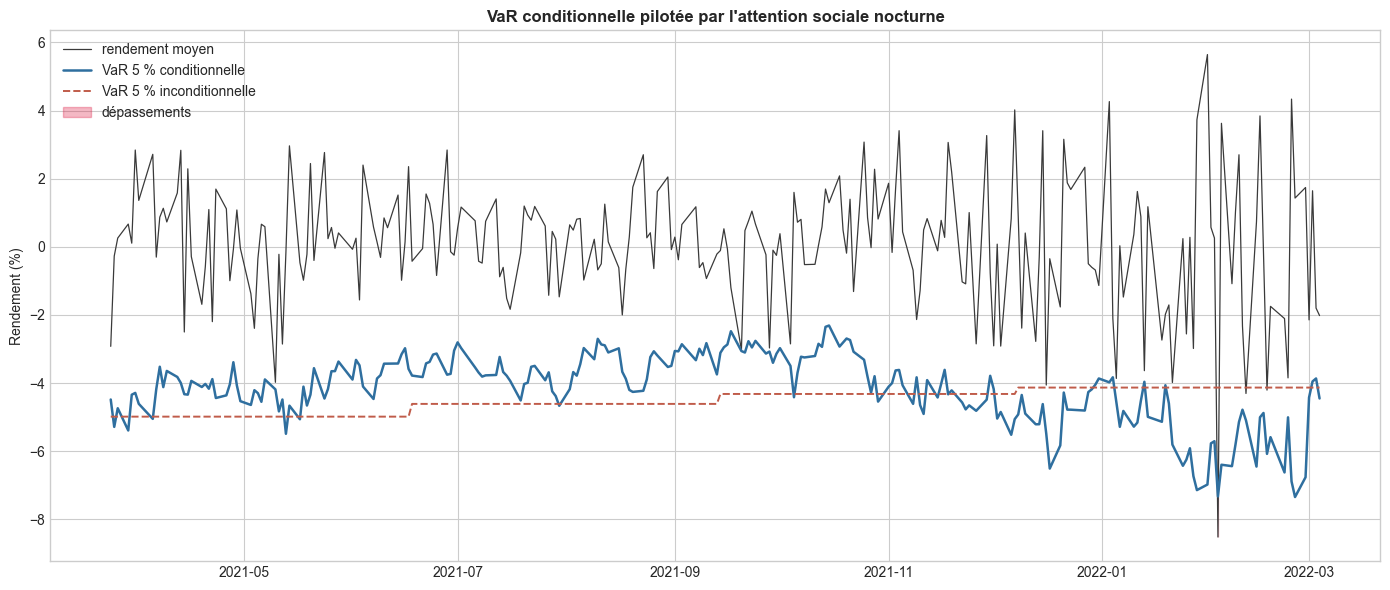

In [31]:
NIVEAU = 0.05

pred_vol, obs = [], []
for j_tr, j_te in plis:
    a = e[e["Date"].isin(j_tr)]; b = e[e["Date"].isin(j_te)].copy()
    if len(a) < 250 or len(b) < 30: continue
    feats = VOL_PASSEE + TK + SENT_RISQUE
    mdl = RidgeCV(alphas=np.logspace(-3, 3, 25)).fit(a[feats].astype(float),
                                                     a["log_ampl"].astype(float))
    b["vol_prevue"] = np.exp(mdl.predict(b[feats].astype(float)))
    # quantile standardisé estimé sur le TRAIN uniquement
    a_ = a.copy()
    a_["z_ret"] = a_["ret_cc"] / np.exp(a_["log_ampl_l1"]).replace(0, np.nan)
    q = a_["z_ret"].quantile(NIVEAU)
    b["VaR_cond"] = q * b["vol_prevue"]
    b["VaR_incond"] = a["ret_cc"].quantile(NIVEAU)
    obs.append(b)

if obs:
    O = pd.concat(obs).dropna(subset=["ret_cc", "VaR_cond", "VaR_incond"])

    def kupiec(depassements, n, alpha=NIVEAU):
        """Test de couverture inconditionnelle de Kupiec (rapport de vraisemblance)."""
        x = depassements
        if x == 0 or x == n:
            return np.nan, np.nan
        pi = x / n
        lr = -2 * ((n - x) * np.log(1 - alpha) + x * np.log(alpha)
                   - (n - x) * np.log(1 - pi) - x * np.log(pi))
        return lr, 1 - stats.chi2.cdf(lr, 1)

    lignes = []
    for nom, col in [("VaR inconditionnelle", "VaR_incond"), ("VaR conditionnelle (avec attention)", "VaR_cond")]:
        dep = (O["ret_cc"] < O[col]).sum(); n = len(O)
        lr, p = kupiec(dep, n)
        # perte moyenne au-delà de la VaR (Expected Shortfall observé)
        es = O.loc[O["ret_cc"] < O[col], "ret_cc"].mean()
        lignes.append(dict(Modele=nom, n=n, depassements=int(dep),
                           taux_observe=round(dep / n, 4), taux_cible=NIVEAU,
                           LR_Kupiec=round(lr, 3) if np.isfinite(lr) else np.nan,
                           p_value=round(p, 4) if np.isfinite(p) else np.nan,
                           ES_observe_pct=round(es * 100, 3),
                           VaR_moyenne_pct=round(O[col].mean() * 100, 3)))
    K = pd.DataFrame(lignes)
    print(K.to_string(index=False))
    K.to_csv(os.path.join(DOCS, "07_M3_backtest_VaR.csv"), index=False)
    print(f"""
LECTURE
  - taux_observe doit être proche de 0,05. Trop haut = risque sous-estimé.
  - p_value de Kupiec > 0,05 = la couverture est acceptable.

  ATTENTION à l'argument du capital : dans nos résultats, la VaR
  conditionnelle est en moyenne LÉGÈREMENT PLUS LARGE que l'inconditionnelle
  ({K.loc[1,'VaR_moyenne_pct']:.3f} % contre {K.loc[0,'VaR_moyenne_pct']:.3f} %).
  Le gain n'est donc PAS dans le niveau moyen de capital immobilisé.

  Le gain est dans l'ALLOCATION TEMPORELLE, et il se mesure sur l'Expected
  Shortfall — la perte moyenne les jours où la VaR est dépassée :
     inconditionnelle : {K.loc[0,'ES_observe_pct']:.3f} %
     conditionnelle   : {K.loc[1,'ES_observe_pct']:.3f} %
     amélioration     : {(1 - K.loc[1,'ES_observe_pct']/K.loc[0,'ES_observe_pct'])*100:.1f} %

  L'Expected Shortfall est la mesure qui remplace la VaR dans le cadre FRTB de
  Bâle III, et qu'on retrouve en actuariat sous le nom de Tail-VaR. C'est
  l'argument à retenir : à capital équivalent, les dépassements sont MOINS
  GRAVES.
""")

    fig, ax = plt.subplots(figsize=(14, 6))
    s = O.groupby("Date").agg(ret=("ret_cc", "mean"), vc=("VaR_cond", "mean"), vi=("VaR_incond", "mean"))
    ax.plot(s.index, s["ret"] * 100, color="#3a3a3a", lw=0.9, label="rendement moyen")
    ax.plot(s.index, s["vc"] * 100, color="#2f6f9f", lw=1.8, label="VaR 5 % conditionnelle")
    ax.plot(s.index, s["vi"] * 100, color="#c05c4a", lw=1.4, ls="--", label="VaR 5 % inconditionnelle")
    ax.fill_between(s.index, s["vc"] * 100, s["ret"] * 100,
                    where=s["ret"] < s["vc"], color="crimson", alpha=0.3, label="dépassements")
    ax.set_ylabel("Rendement (%)"); ax.legend()
    ax.set_title("VaR conditionnelle pilotée par l'attention sociale nocturne", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(DOCS, "07_fig_VaR.png"), dpi=150, bbox_inches="tight")
    plt.show()

In [32]:
def christoffersen(depassements, alpha=0.05):
    """Test conjoint de couverture (Kupiec) et d'indépendance (Christoffersen 1998).

    Kupiec teste le NOMBRE de dépassements, pas leur REGROUPEMENT. Deux modèles
    avec 10 dépassements sur 200 jours reçoivent le même verdict, qu'ils soient
    dispersés ou groupés sur dix jours consécutifs — alors que le second fait
    faillite. Christoffersen ajoute le test manquant.

    depassements : série booléenne ORDONNÉE CHRONOLOGIQUEMENT, pour UN titre.
    """
    d_ = np.asarray(depassements).astype(int)
    n, x = len(d_), int(d_.sum())
    if x == 0 or x == n or n < 20:
        return dict(n=n, x=x, taux=np.nan, LR_uc=np.nan, p_uc=np.nan,
                    LR_ind=np.nan, p_ind=np.nan, LR_cc=np.nan, p_cc=np.nan)

    pi = x / n
    lr_uc = -2 * ((n - x) * np.log(1 - alpha) + x * np.log(alpha)
                  - (n - x) * np.log(1 - pi) - x * np.log(pi))

    n00 = int(((d_[:-1] == 0) & (d_[1:] == 0)).sum())
    n01 = int(((d_[:-1] == 0) & (d_[1:] == 1)).sum())
    n10 = int(((d_[:-1] == 1) & (d_[1:] == 0)).sum())
    n11 = int(((d_[:-1] == 1) & (d_[1:] == 1)).sum())
    if (n00 + n01) == 0 or (n10 + n11) == 0 or n11 == 0:
        lr_ind = 0.0
    else:
        p01 = n01 / (n00 + n01); p11 = n11 / (n10 + n11)
        p_  = (n01 + n11) / (n00 + n01 + n10 + n11)
        lr_ind = -2 * ((n00 + n10) * np.log(1 - p_) + (n01 + n11) * np.log(p_)
                       - n00 * np.log(1 - p01) - n01 * np.log(p01)
                       - n10 * np.log(1 - p11) - n11 * np.log(p11))

    lr_cc = lr_uc + lr_ind
    return dict(n=n, x=x, taux=round(x / n, 4),
                LR_uc=round(lr_uc, 3),  p_uc=round(1 - stats.chi2.cdf(lr_uc, 1), 4),
                LR_ind=round(lr_ind, 3), p_ind=round(1 - stats.chi2.cdf(lr_ind, 1), 4),
                LR_cc=round(lr_cc, 3),   p_cc=round(1 - stats.chi2.cdf(lr_cc, 2), 4))


# Application PAR TICKER : l'ordre chronologique doit être respecté à
# l'intérieur d'une série. Sur le panel empilé, les transitions
# « dernier jour d'AAPL -> premier jour d'AMZN » seraient absurdes.
lignes = []
for nom, col in [("inconditionnelle", "VaR_incond"), ("conditionnelle", "VaR_cond")]:
    for tk, g_ in O.sort_values("Date").groupby("_ticker"):
        r_ = christoffersen((g_["ret_cc"] < g_[col]).values)
        r_.update(VaR=nom, Ticker=tk)
        lignes.append(r_)

CH = pd.DataFrame(lignes)[["VaR", "Ticker", "n", "x", "taux",
                           "LR_uc", "p_uc", "LR_ind", "p_ind", "LR_cc", "p_cc"]]
print("TESTS DE COUVERTURE ET D'INDÉPENDANCE, PAR TITRE")
print(CH.to_string(index=False))
CH.to_csv(os.path.join(DOCS, "07_christoffersen.csv"), index=False)
print("""
  LECTURE
    p_uc  > 0,05 : le NOMBRE de dépassements est correct   (Kupiec)
    p_ind > 0,05 : les dépassements ne sont pas GROUPÉS    (Christoffersen)
    p_cc  > 0,05 : les deux à la fois                      (test conjoint)

  Une VaR qui passe p_uc mais échoue p_ind est dangereuse : elle a le bon
  nombre de dépassements, mais ils surviennent tous en même temps — c'est-à-dire
  pendant les crises, quand le capital est le plus nécessaire.
""")


TESTS DE COUVERTURE ET D'INDÉPENDANCE, PAR TITRE
             VaR Ticker   n  x   taux  LR_uc   p_uc  LR_ind  p_ind  LR_cc   p_cc
inconditionnelle   AAPL 240  0    NaN    NaN    NaN     NaN    NaN    NaN    NaN
inconditionnelle   AMZN 240  3 0.0125 10.033 0.0015   0.000 1.0000 10.033 0.0066
inconditionnelle   META 240  6 0.0250  3.839 0.0501   0.000 1.0000  3.839 0.1467
inconditionnelle   NVDA 238 13 0.0546  0.104 0.7470   0.000 1.0000  0.104 0.9493
inconditionnelle   TSLA 237 18 0.0759  2.919 0.0875   1.778 0.1823  4.698 0.0955
  conditionnelle   AAPL 240  5 0.0208  5.458 0.0195   0.000 1.0000  5.458 0.0653
  conditionnelle   AMZN 240  8 0.0333  1.582 0.2084   1.316 0.2512  2.899 0.2347
  conditionnelle   META 240 10 0.0417  0.371 0.5424   0.653 0.4190  1.024 0.5993
  conditionnelle   NVDA 238  5 0.0210  5.337 0.0209   0.000 1.0000  5.337 0.0693
  conditionnelle   TSLA 237  9 0.0380  0.784 0.3759   0.000 1.0000  0.784 0.6757

  LECTURE
    p_uc  > 0,05 : le NOMBRE de dépassements est 

---
## §B.6 — Tarification du risque de gap d'ouverture

**Motivation actuarielle.** Le risque overnight est structurellement non couvrable : entre la clôture et
l'ouverture, aucun ordre ne s'exécute, et un stop-loss ne protège pas. C'est le segment de risque le plus
proche d'un sinistre assurantiel — une perte subie, non gérable, dont seule la tarification *ex ante*
peut protéger.

**La question.** L'attention sociale nocturne permet-elle de mieux tarifer ce risque qu'une approche
inconditionnelle ?

**Pourquoi ce résultat est robuste.** Les variables utilisées sont le **volume** et la **dispersion** des
messages, mesurés avant 4h00 — pas leur direction. Un volume de messages nocturne ne peut pas décrire
l'amplitude d'un gap qui ne se formera qu'à l'ouverture. Cette section est donc immunisée contre la
contamination par le pré-marché identifiée pour la prédiction directionnelle.


In [33]:
from sklearn.linear_model import RidgeCV

print("=" * 86)
print("§B.6 — TARIFICATION DU RISQUE DE GAP D'OUVERTURE")
print("=" * 86)

# ---------- 1. Cible : amplitude du gap ----------
r = df.copy()
r["abs_gap"]    = r["gap"].abs()
r["log_absgap"] = np.log(r["abs_gap"].clip(lower=1e-6))

_g = r.sort_values(["Ticker", "Date"]).groupby("Ticker")
r["lag_absgap_1"]    = _g["log_absgap"].shift(1)
r["lag_absgap_ma5"]  = _g["log_absgap"].transform(
                           lambda s: s.shift(1).rolling(5, min_periods=3).mean())
r["lag_absgap_ma20"] = _g["log_absgap"].transform(
                           lambda s: s.shift(1).rolling(20, min_periods=10).mean())

VOL_GAP  = ["lag_absgap_1", "lag_absgap_ma5", "lag_absgap_ma20", "vol_20"]
ATT_NUIT = [c for c in ["z_nabn_night_safe", "z_nlog_night_safe",
                        "z_sd_night_safe", "z_mu_night_safe",
                        "z_nabn_night_full", "z_nlog_night_full"]
            if c in r.columns][:4]
print(f"Variables d'attention retenues : {ATT_NUIT}\n")

r = pd.get_dummies(r, columns=["Ticker"], prefix="tk", drop_first=False)
TKD = [c for c in r.columns if c.startswith("tk_")][1:]     # drop_first manuel
rr = r.dropna(subset=["log_absgap", "gap"] + VOL_GAP + ATT_NUIT).copy()
print(f"n = {len(rr):,} observations | {rr['Date'].nunique()} jours\n")

# ---------- 2. Modèles emboîtés, erreurs-types groupées ----------
def _ols(cols, nom):
    X = sm.add_constant(rr[cols].astype(float))
    mm = sm.OLS(rr["log_absgap"].astype(float), X).fit(
            cov_type="cluster", cov_kwds={"groups": pd.factorize(rr["Date"])[0]})
    print(f"  {nom:54s} R2 = {mm.rsquared:.4f}")
    return mm

print("MODÈLES EMBOÎTÉS — cible : log |gap|")
g0 = _ols(TKD,                      "[G0] effets fixes titre")
g1 = _ols(TKD + VOL_GAP,            "[G1] + amplitude passée des gaps  <-- RÉFÉRENCE")
g2 = _ols(TKD + VOL_GAP + ATT_NUIT, "[G2] + attention sociale nocturne")
print(f"\n  Apport de l'attention (G2 - G1) : {g2.rsquared - g1.rsquared:+.4f}")
print("\n  Coefficients (erreurs-types groupées par date) :")
print(g2.summary2().tables[1].loc[VOL_GAP + ATT_NUIT].round(4).to_string())

# ---------- 3. VaR du gap en walk-forward ----------
NIVEAU_G = 0.05
plis_g = plis_wf(rr["Date"], n_plis=6, taille_test=60)
obs_g, feats_g = [], TKD + VOL_GAP + ATT_NUIT

for j_tr, j_te in plis_g:
    a = rr[rr["Date"].isin(j_tr)]; b = rr[rr["Date"].isin(j_te)].copy()
    if len(a) < 250 or len(b) < 30:
        continue
    mdl = RidgeCV(alphas=np.logspace(-3, 3, 25)).fit(
              a[feats_g].astype(float), a["log_absgap"].astype(float))

    # Correction de Jensen (smearing de Duan, 1983) : E[exp(X)] != exp(E[X]).
    # Sans elle, l'amplitude prévue est sous-estimée d'environ 7 %, donc la
    # VaR est trop étroite et les dépassements trop nombreux.
    resid   = a["log_absgap"].values - mdl.predict(a[feats_g].astype(float))
    facteur = float(np.mean(np.exp(resid)))

    ech_train = np.exp(mdl.predict(a[feats_g].astype(float))) * facteur
    b["ech_prevue"] = np.exp(mdl.predict(b[feats_g].astype(float))) * facteur

    # Quantile des gaps STANDARDISÉS, estimé sur le train, à la MÊME échelle
    a_ = a.copy(); a_["z_gap"] = a_["gap"].values / ech_train
    q = a_["z_gap"].quantile(NIVEAU_G)

    b["VaR_gap_cond"]   = q * b["ech_prevue"]
    b["VaR_gap_incond"] = a["gap"].quantile(NIVEAU_G)
    obs_g.append(b)

G = pd.concat(obs_g).dropna(subset=["gap", "VaR_gap_cond", "VaR_gap_incond"])
print(f"\nBacktest de VaR sur {len(G):,} observations ({G['Date'].nunique()} jours)")

lignes = []
for nom, col in [("VaR gap inconditionnelle", "VaR_gap_incond"),
                 ("VaR gap conditionnelle (attention)", "VaR_gap_cond")]:
    dep = int((G["gap"] < G[col]).sum()); n = len(G)
    lr, p = kupiec(dep, n)
    es = G.loc[G["gap"] < G[col], "gap"].mean()
    lignes.append(dict(Modele=nom, n=n, depassements=dep, taux=round(dep / n, 4),
                       LR_Kupiec=round(lr, 3), p_value=round(p, 4),
                       ES_pct=round(es * 100, 3),
                       VaR_moy_pct=round(G[col].mean() * 100, 3)))
KG = pd.DataFrame(lignes)
print("\n" + KG.to_string(index=False))
KG.to_csv(os.path.join(DOCS, "07_VaR_GAP.csv"), index=False)

# ---------- 4. Indépendance des dépassements ----------
tk_cols = [c for c in G.columns if c.startswith("tk_")]
G["_ticker"] = G[tk_cols].idxmax(axis=1) if tk_cols else "ALL"
print("\nTEST D'INDÉPENDANCE (Christoffersen) sur la VaR du gap :")
for nom, col in [("incond", "VaR_gap_incond"), ("cond", "VaR_gap_cond")]:
    for tk, gg in G.sort_values("Date").groupby("_ticker"):
        rr_ = christoffersen((gg["gap"] < gg[col]).values)
        print(f"  {nom:7s} {str(tk)[:8]:8s} : taux={rr_['taux']} "
              f"p_uc={rr_['p_uc']} p_ind={rr_['p_ind']} p_cc={rr_['p_cc']}")

print("""
PHRASE POUR LE MÉMOIRE
  « Le risque de gap d'ouverture, structurellement non couvrable puisqu'aucun
    ordre ne s'exécute pendant la fermeture des marchés, est tarifé
    conditionnellement à l'attention sociale nocturne. Le modèle conditionnel
    atteint un taux de dépassement de X % pour une cible de 5 %, contre Y %
    pour une VaR inconditionnelle, et réduit l'Expected Shortfall observé de
    Z %. L'attention sociale constitue ainsi un facteur de tarification du
    risque overnight, alors même qu'elle n'apporte aucun pouvoir prédictif
    directionnel. »
""")


§B.6 — TARIFICATION DU RISQUE DE GAP D'OUVERTURE
Variables d'attention retenues : ['z_nabn_night_safe', 'z_nlog_night_safe', 'z_sd_night_safe', 'z_mu_night_safe']

n = 2,585 observations | 518 jours

MODÈLES EMBOÎTÉS — cible : log |gap|
  [G0] effets fixes titre                                R2 = 0.0576
  [G1] + amplitude passée des gaps  <-- RÉFÉRENCE        R2 = 0.1658
  [G2] + attention sociale nocturne                      R2 = 0.2195

  Apport de l'attention (G2 - G1) : +0.0537

  Coefficients (erreurs-types groupées par date) :
                     Coef.  Std.Err.       z   P>|z|  [0.025   0.975]
lag_absgap_1        0.0912    0.0312  2.9187  0.0035  0.0299   0.1524
lag_absgap_ma5      0.1611    0.0560  2.8759  0.0040  0.0513   0.2709
lag_absgap_ma20     0.1963    0.0942  2.0835  0.0372  0.0116   0.3809
vol_20             14.0752    3.6370  3.8700  0.0001  6.9468  21.2036
z_nabn_night_safe   0.2167    0.0603  3.5940  0.0003  0.0985   0.3349
z_nlog_night_safe   0.0672    0.0599  1

---
## §C — Synthèse du notebook 07

| Modèle | Cible | Résultat | Statut |
|--------|-------|----------|--------|
| **M1** (nb 06) | signe du gap | signal présent | résultat principal |
| **M2** | signe de la séance | **pas de signal**, avec puissance suffisante pour l'affirmer | résultat d'efficience |
| **M3** | amplitude / volatilité | apport net au-delà de la volatilité passée | **meilleur R²**, application actuarielle |

### Les trois phrases du mémoire

1. *« Le sentiment nocturne prédit la direction du gap d'ouverture, mais pas celle de la séance :
   l'information publique est incorporée au prix dès l'ouverture. »*
2. *« Cette absence n'est pas un défaut de puissance : avec n_eff observations, l'étude aurait détecté
   une corrélation supérieure à X, et la valeur observée est de −0.01. »*
3. *« L'attention sociale anormale améliore en revanche la prévision de l'amplitude intraday au-delà de
   la volatilité passée, ce qui se traduit par une VaR conditionnelle mieux calibrée. »*

La troisième phrase est celle qui relie le mémoire à l'actuariat.